# Trying the MVR method

Dependent Variable (Y): The target for the regression model is the NDVI correction term itself, calculated at each time step t using the data from the calibration tarps. This is the time series of the residual error that needs to be modeled and removed from the field pixel data.

NDVI_Correction(t)= (NDVI true, tarp(t)) − (NDVI observed, tarp(t))

**Because my hyperspectral data for tarps in not on the same dates as the Satellite data, I will do a linear regression for the hyperspectral Tarp dat and from that I will find the True NDVI values for the tarp for dates of the satellite Images**

Independent Variables (Predictors, X): The set of predictors should include variables that can explain the variability in the NDVI_Correction. A well-chosen set of predictors allows the model to become context-aware, tailoring the correction based on the specific conditions at each time point.

Observed Tarp NDVI (NDVI 
observed, tarp
​
 (t)): The magnitude of the error may not be constant across the range of NDVI values. For example, atmospheric effects might be more pronounced for low-reflectance surfaces. Including the observed NDVI as a predictor allows the model to learn a level-dependent correction.

Observed Tarp Red and NIR Reflectances (ρ 
Red, obs, tarp
​
 (t),ρ 
NIR, obs, tarp
​
 (t)): Atmospheric effects are strongly wavelength-dependent. Path radiance, for instance, is much greater in the red band than in the NIR band due to atmospheric scattering. By including the individual band reflectances as separate predictors, the model can learn to attribute the error more accurately to its source. For example, it might learn that a high observed red reflectance (indicative of haze) requires a specific type of correction.   

Observed Pixel NDVI (NDVI 
observed, pixel
​
 (t)): The correction required for a given field pixel might also depend on the brightness of that pixel itself. This can be related to the "adjacency effect," where radiance from bright neighboring pixels scatters into the sensor's view of a darker target pixel, altering its apparent reflectance. Including the pixel's own NDVI allows the model to scale the correction based on the target's characteristics.   

Interaction Terms: The effect of one predictor may depend on the level of another. For instance, the impact of atmospheric haze (captured by ρ 
Red, obs, tarp
​
 ) might be different for a dense canopy (high NDVI 
observed, pixel
​
 ) than for bare soil (low NDVI 
observed, pixel
​
 ). Interaction terms, such as ρ 
Red, obs, tarp
​
 (t)×NDVI 
observed, pixel
​
 (t), can capture these more complex relationships.

 The final MLR model to be trained on the time series of tarp data would take the form:

NDVI_Correction(t)=β 
0
​
 +β 
1
​
 NDVI 
obs, tarp
​
 (t)+β 
2
​
 ρ 
Red, obs, tarp
​
 (t)+β 
3
​
 ρ 
NIR, obs, tarp
​
 (t)+β 
4
​
 NDVI 
obs, pixel
​
 (t)+⋯+ε(t)
Once the model is trained and the coefficients (β 
i
​
 ) are estimated, it can be used to predict the correction for any field pixel at any time point t using the observed values of the predictors for that pixel. The final corrected NDVI for the field pixel is then:

NDVI 
corrected, pixel
​
 (t)=NDVI 
observed, pixel
​
 (t)+Predicted_NDVI_Correction(t)

In [1]:
# --- Core Data Handling & Numerical Operations ---
import pandas as pd
import numpy as np

# --- Machine Learning & Regression Models ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA

# --- Time Series Specific Models & Tools ---
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Optional: Advanced time series modeling ---
# from pykalman import KalmanFilter # For Kalman Filtering/Smoothing

# --- Set plotting styles for better visuals ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
# getting the p6 scaled data
df_p6_scaled = pd.read_csv("D:\Capstone\Data\main_data\pixel_6_scaled.csv")
df_dtw = pd.read_csv(r"D:\Capstone\Data\tarp_modelling_data\df_dtw.csv")
h_tarps = pd.read_csv(r"D:\Capstone\EDA\hyperspectral_tarps.csv")

In [8]:
h_tarps

,wavelength,2023-06-02_Red,2023-06-02_White,2023-06-06_Red,2023-06-06_White,2023-06-20_Red,2023-06-20_White,2023-06-22_Red,2023-06-22_White,2023-07-06_Red,2023-07-06_White,2023-07-11_Red,2023-07-11_White,2023-07-13_Red,2023-07-13_White,2023-07-19_Red,2023-07-19_White,2023-08-09_Red,2023-08-09_White
0,325,0.171367,0.179652,0.131632,0.177270,0.095037,0.147242,0.212425,0.196478,0.144186,0.175855,0.153050,0.186087,0.134239,0.126278,0.107972,0.150048,0.121940,0.181262
1,326,0.166546,0.174429,0.158997,0.211772,0.097379,0.142664,0.206974,0.191182,0.140737,0.169954,0.143746,0.178369,0.131324,0.118785,0.103745,0.145318,0.119027,0.170491
2,327,0.163021,0.168820,0.170239,0.235909,0.104310,0.146799,0.204400,0.188852,0.139908,0.166811,0.136840,0.171089,0.132997,0.119723,0.103486,0.143698,0.117080,0.163871
3,328,0.161551,0.163107,0.148788,0.219944,0.112717,0.158890,0.207365,0.191233,0.140257,0.166065,0.138850,0.168407,0.139880,0.131453,0.107564,0.144827,0.116059,0.164482
4,329,0.152131,0.155290,0.125634,0.193787,0.109099,0.155912,0.204799,0.187903,0.140657,0.167603,0.135645,0.164052,0.135055,0.127587,0.107141,0.143876,0.120354,0.168691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,1071,0.648676,0.896041,0.650976,0.935839,0.377995,0.698128,0.877726,0.947733,0.578602,0.830663,0.615804,0.882392,0.632442,0.742287,0.429691,0.674336,0.531114,0.807730
747,1072,0.650528,0.894542,0.646791,0.937034,0.435138,0.720364,0.888929,0.955636,0.570966,0.833640,0.583522,0.864001,0.633816,0.726724,0.441520,0.683999,0.540063,0.815119
748,1073,0.635839,0.889750,0.648413,0.932444,0.440133,0.728642,0.879398,0.952323,0.554064,0.829111,0.560804,0.843424,0.643958,0.734580,0.453258,0.689308,0.535991,0.807829
749,1074,0.617331,0.891458,0.651118,0.926405,0.398925,0.721811,0.855351,0.938719,0.543908,0.825688,0.558541,0.836350,0.655533,0.761552,0.459144,0.687653,0.518282,0.788441


In [10]:
df_h_red = h_tarps.query("650 <= `wavelength` <= 680").mean()
df_h_nir = h_tarps.query("845 <= `wavelength` <= 885").mean()

In [17]:
df_h_red = pd.DataFrame(df_h_red)
df_h_nir = pd.DataFrame(df_h_nir)

In [23]:
# Calculate the mean Series, but drop the wavelength mean which isn't a reflectance
red_means = h_tarps.query("650 <= `wavelength` <= 680").drop('wavelength', axis=1).mean()
nir_means = h_tarps.query("845 <= `wavelength` <= 885").drop('wavelength', axis=1).mean()

# Create single-row DataFrames
df_h_red_wide = pd.DataFrame([red_means])
df_h_nir_wide = pd.DataFrame([nir_means])

# You can add a label for the band
df_h_red_wide.index = ['red']
df_h_nir_wide.index = ['nir']


print("--- Red Band Wide DataFrame ---")
print(df_h_red_wide)
print("\n--- NIR Band Wide DataFrame ---")
print(df_h_nir_wide)

--- Red Band Wide DataFrame ---
     2023-06-02_Red  2023-06-02_White  2023-06-06_Red  2023-06-06_White  \
red        0.617744          0.852637        0.611422          0.924371   

     2023-06-20_Red  2023-06-20_White  2023-06-22_Red  2023-06-22_White  \
red        0.489462          0.852176        0.969527          1.064497   

     2023-07-06_Red  2023-07-06_White  2023-07-11_Red  2023-07-11_White  \
red        0.576169          0.846298        0.618024          0.909967   

     2023-07-13_Red  2023-07-13_White  2023-07-19_Red  2023-07-19_White  \
red        0.748571          0.821282        0.471221          0.713118   

     2023-08-09_Red  2023-08-09_White  
red        0.559356          0.873925  

--- NIR Band Wide DataFrame ---
     2023-06-02_Red  2023-06-02_White  2023-06-06_Red  2023-06-06_White  \
nir         0.64155          0.840224        0.625218          0.897512   

     2023-06-20_Red  2023-06-20_White  2023-06-22_Red  2023-06-22_White  \
nir        0.466949      

In [26]:
df_h_red = df_h_red_wide.T
df_h_nir = df_h_nir_wide.T

In [32]:
df_h_tarp = df_h_red.merge(df_h_nir, on = df_h_red.index)

In [36]:
df_h_tarp

,key_0,red,nir
0,2023-06-02_Red,0.617744,0.641550
1,2023-06-02_White,0.852637,0.840224
2,2023-06-06_Red,0.611422,0.625218
3,2023-06-06_White,0.924371,0.897512
4,2023-06-20_Red,0.489462,0.466949
5,2023-06-20_White,0.852176,0.771788
6,2023-06-22_Red,0.969527,0.934674
7,2023-06-22_White,1.064497,0.977214
8,2023-07-06_Red,0.576169,0.581923
9,2023-07-06_White,0.846298,0.803356


In [41]:
df_h_red_tarp = df_h_tarp[df_h_tarp.key_0.str.endswith("Red")]
df_h_white_tarp = df_h_tarp[df_h_tarp.key_0.str.endswith("White")]

In [45]:
df_h_red_tarp.columns = ['Date', 'red_tarp_red', 'red_tarp_nir']
df_h_white_tarp.columns = ['Date', 'white_tarp_red', 'white_tarp_nir']

In [58]:
df_h_red_tarp, df_h_white_tarp

(         Date  red_tarp_red  red_tarp_nir
 0  2023-06-02      0.617744      0.641550
 2  2023-06-06      0.611422      0.625218
 4  2023-06-20      0.489462      0.466949
 6  2023-06-22      0.969527      0.934674
 8  2023-07-06      0.576169      0.581923
 10 2023-07-11      0.618024      0.602657
 12 2023-07-13      0.748571      0.720382
 14 2023-07-19      0.471221      0.480629
 16 2023-08-09      0.559356      0.546464,
           Date  white_tarp_red  white_tarp_nir
 1   2023-06-02        0.852637        0.840224
 3   2023-06-06        0.924371        0.897512
 5   2023-06-20        0.852176        0.771788
 7   2023-06-22        1.064497        0.977214
 9   2023-07-06        0.846298        0.803356
 11  2023-07-11        0.909967        0.838060
 13  2023-07-13        0.821282        0.782438
 15  2023-07-19        0.713118        0.685703
 17  2023-08-09        0.873925        0.791959)

In [52]:
df_h_red_tarp.Date = df_h_red_tarp.Date.str[0:10]
df_h_white_tarp.Date = df_h_white_tarp.Date.str[0:10]

C:\Users\omkar\AppData\Local\Temp\ipykernel_67080\2436669248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_h_red_tarp.Date = df_h_red_tarp.Date.str[0:10]
C:\Users\omkar\AppData\Local\Temp\ipykernel_67080\2436669248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_h_white_tarp.Date = df_h_white_tarp.Date.str[0:10]


In [ ]:
df_h_red_tarp.Date = pd.to_datetime(df_h_red_tarp.Date)
df_h_white_tarp.Date = pd.to_datetime(df_h_white_tarp.Date)

C:\Users\omkar\AppData\Local\Temp\ipykernel_67080\1577206283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_h_white_tarp.Date = pd.to_datetime(df_h_white_tarp.Date)


In [60]:
df_h_red_tarp.info(), df_h_white_tarp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 0 to 16
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          9 non-null      datetime64[ns]
 1   red_tarp_red  9 non-null      float64       
 2   red_tarp_nir  9 non-null      float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 588.0 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 1 to 17
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            9 non-null      datetime64[ns]
 1   white_tarp_red  9 non-null      float64       
 2   white_tarp_nir  9 non-null      float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 288.0 bytes


(None, None)

In [61]:
df_h_tarp = pd.merge(df_h_red_tarp,df_h_white_tarp, on = 'Date')

In [62]:
df_h_tarp


,Date,red_tarp_red,red_tarp_nir,white_tarp_red,white_tarp_nir
0,2023-06-02,0.617744,0.641550,0.852637,0.840224
1,2023-06-06,0.611422,0.625218,0.924371,0.897512
2,2023-06-20,0.489462,0.466949,0.852176,0.771788
3,2023-06-22,0.969527,0.934674,1.064497,0.977214
4,2023-07-06,0.576169,0.581923,0.846298,0.803356
5,2023-07-11,0.618024,0.602657,0.909967,0.838060
6,2023-07-13,0.748571,0.720382,0.821282,0.782438
7,2023-07-19,0.471221,0.480629,0.713118,0.685703
8,2023-08-09,0.559356,0.546464,0.873925,0.791959


In [67]:
df_h_tarp['red_tarp_NDVI'] = ((df_h_tarp.red_tarp_nir - df_h_tarp.red_tarp_red)/(df_h_tarp.red_tarp_nir + df_h_tarp.red_tarp_red))
df_h_tarp['white_tarp_NDVI'] = ((df_h_tarp.white_tarp_nir - df_h_tarp.white_tarp_red)/(df_h_tarp.white_tarp_nir + df_h_tarp.white_tarp_red))


In [71]:
df_h_tarp

,Date,red_tarp_red,red_tarp_nir,white_tarp_red,white_tarp_nir,red_tarp_NDVI,white_tarp_NDVI
0,2023-06-02,0.617744,0.641550,0.852637,0.840224,0.018904,-0.007332
1,2023-06-06,0.611422,0.625218,0.924371,0.897512,0.011157,-0.014742
2,2023-06-20,0.489462,0.466949,0.852176,0.771788,-0.023539,-0.049501
3,2023-06-22,0.969527,0.934674,1.064497,0.977214,-0.018303,-0.042750
4,2023-07-06,0.576169,0.581923,0.846298,0.803356,0.004968,-0.026031
5,2023-07-11,0.618024,0.602657,0.909967,0.838060,-0.012589,-0.041137
6,2023-07-13,0.748571,0.720382,0.821282,0.782438,-0.019190,-0.024221
7,2023-07-19,0.471221,0.480629,0.713118,0.685703,0.009884,-0.019598
8,2023-08-09,0.559356,0.546464,0.873925,0.791959,-0.011659,-0.049202


In [82]:
# For pixel 6 ther day of planting in 2023-05-16
df_h_tarp["dap"] = df_h_tarp['Date'] - pd.to_datetime('2023-05-16')

In [83]:
df_h_tarp.dap = df_h_tarp.dap.dt.days

In [96]:
df_h_tarp
# df_h_tarp.to_csv(r"D:\Capstone\Data\tarp_modelling_data\df_h_tarp_2023.csv")


,Date,red_tarp_red,red_tarp_nir,white_tarp_red,white_tarp_nir,red_tarp_NDVI,white_tarp_NDVI,dap
0,2023-06-02,0.617744,0.641550,0.852637,0.840224,0.018904,-0.007332,17
1,2023-06-06,0.611422,0.625218,0.924371,0.897512,0.011157,-0.014742,21
2,2023-06-20,0.489462,0.466949,0.852176,0.771788,-0.023539,-0.049501,35
3,2023-06-22,0.969527,0.934674,1.064497,0.977214,-0.018303,-0.042750,37
4,2023-07-06,0.576169,0.581923,0.846298,0.803356,0.004968,-0.026031,51
5,2023-07-11,0.618024,0.602657,0.909967,0.838060,-0.012589,-0.041137,56
6,2023-07-13,0.748571,0.720382,0.821282,0.782438,-0.019190,-0.024221,58
7,2023-07-19,0.471221,0.480629,0.713118,0.685703,0.009884,-0.019598,64
8,2023-08-09,0.559356,0.546464,0.873925,0.791959,-0.011659,-0.049202,85


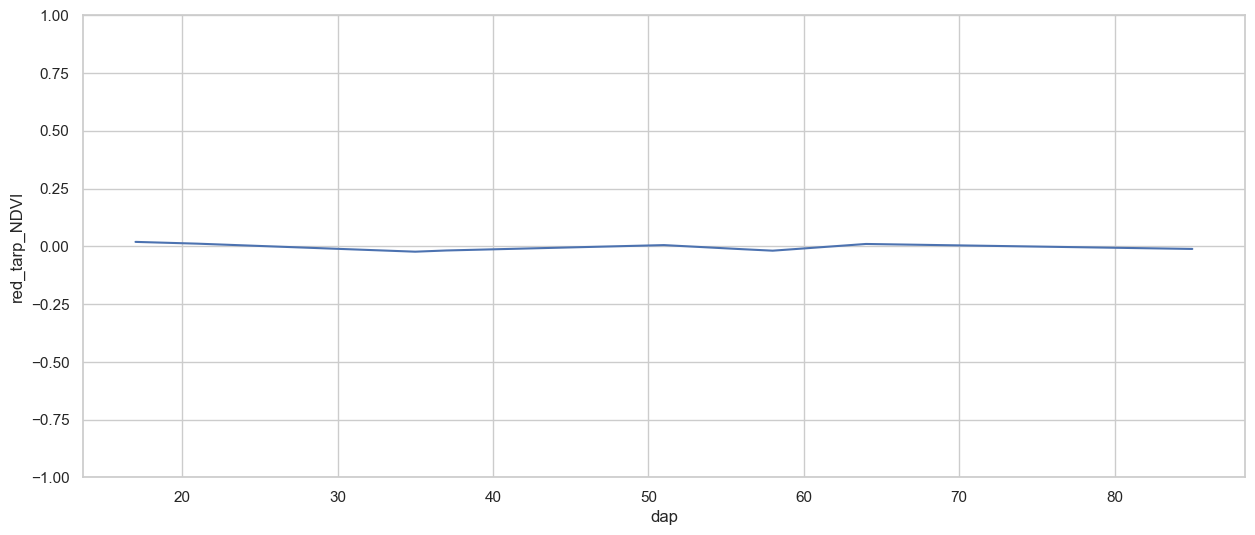

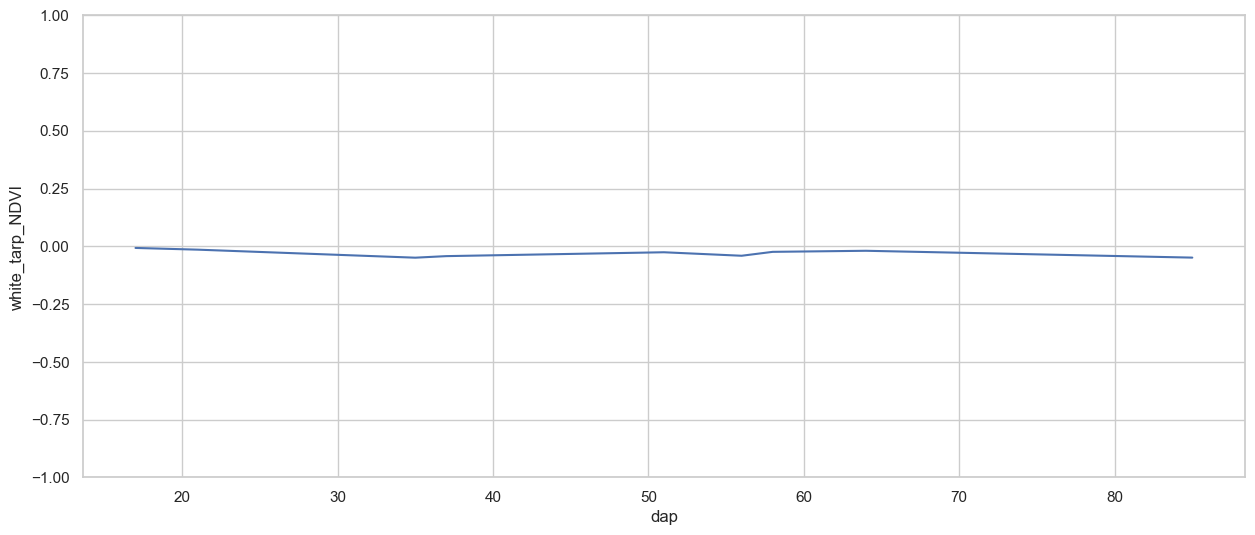

In [93]:
# Create a line plot
sns.lineplot(data=df_h_tarp, x='dap', y='red_tarp_NDVI')

plt.ylim(-1,1)


# Display the plot
plt.show()

# Create a line plot
sns.lineplot(data=df_h_tarp, x='dap', y='white_tarp_NDVI')

plt.ylim(-1,1)


# Display the plot
plt.show()

In [114]:
from sklearn.linear_model import LinearRegression
# Assuming df_h_tarp is your DataFrame

# 1. Create an empty dictionary to store your trained models
models = {}

dependent_columns = ["red_tarp_NDVI", "white_tarp_NDVI"]

# 2. Loop through your columns just like before
print("--- Starting Model Training ---")
for col in dependent_columns:
    print(f"Training model for: {col}")
    
    # Define X and y
    X = df_h_tarp[['dap']] 
    y_true = df_h_tarp[col]
    
    # Create a new model instance for this loop iteration
    model = LinearRegression()
    
    # Fit the model
    model.fit(X, y_true)
    
    # 3. Store the fully trained model in the dictionary
    # The column name (e.g., "red_tarp_NDVI") becomes the key
    models[col] = model

print("\n--- Model Training Complete ---")
print("Models stored in the dictionary:", list(models.keys()))

--- Starting Model Training ---
Training model for: red_tarp_NDVI
Training model for: white_tarp_NDVI

--- Model Training Complete ---
Models stored in the dictionary: ['red_tarp_NDVI', 'white_tarp_NDVI']


In [159]:
import numpy as np
# Assuming 'models' and 'df_dtw' are already defined

# To get the models:
red_model = models['red_tarp_NDVI']
white_model = models['white_tarp_NDVI']

# This is your input data for prediction
prediction_input_original = df_dtw[['dap_from_p6_scaled']]

# FIX: Rename the column to match what the model was trained on
# We are renaming 'dap_from_p6_scaled' to 'dap'
dap_to_predict = prediction_input_original.rename(columns={'dap_from_p6_scaled': 'dap'})

# Let's check the new column name
print("Column name for prediction:", dap_to_predict.columns)


# Now the predict functions will work because the column name is correct
predicted_red_ndvi = red_model.predict(dap_to_predict)
predicted_white_ndvi = white_model.predict(dap_to_predict)


# 3. Assign the prediction arrays as new columns
df_dtw['predicted_red_tarp_ndvi'] = predicted_red_ndvi
df_dtw['predicted_white_tarp_ndvi'] = predicted_white_ndvi


# 4. Verify that the new columns have been added
print("--- DataFrame with New Prediction Columns ---")
# Display the original DAP column and the two new prediction columns
print(df_dtw[['dap_from_p6_scaled', 'predicted_red_tarp_ndvi', 'predicted_white_tarp_ndvi']].head())


Column name for prediction: Index(['dap'], dtype='object')
--- DataFrame with New Prediction Columns ---
   dap_from_p6_scaled  predicted_red_tarp_ndvi  predicted_white_tarp_ndvi
0                 0.0                 0.007592                  -0.014406
1                 2.0                 0.007080                  -0.015089
2                10.0                 0.005029                  -0.017822
3                11.0                 0.004772                  -0.018164
4                12.0                 0.004516                  -0.018506


In [160]:
df_dtw['predicted_red_tarp_ndvi_resid'] = df_dtw['red_tarp_ndvi'] - df_dtw['predicted_red_tarp_ndvi']
df_dtw['predicted_white_tarp_ndvi_resid'] = df_dtw['white_tarp_ndvi'] - df_dtw['predicted_white_tarp_ndvi']

# Subtract predicted residuals from pixel_6_ndvi
df_dtw['pixel_6_ndvi_minus_predicted_red_residual'] = df_dtw['pixel_6_ndvi'] - df_dtw['predicted_red_tarp_ndvi_resid']
df_dtw['pixel_6_ndvi_minus_predicted_white_residual'] = df_dtw['pixel_6_ndvi'] - df_dtw['predicted_white_tarp_ndvi_resid']

# Add predicted residuals to pixel_6_ndvi
df_dtw['pixel_6_ndvi_plus_predicted_red_residual'] = df_dtw['pixel_6_ndvi'] + df_dtw['predicted_red_tarp_ndvi_resid']
df_dtw['pixel_6_ndvi_plus_predicted_white_residual'] = df_dtw['pixel_6_ndvi'] + df_dtw['predicted_white_tarp_ndvi_resid']

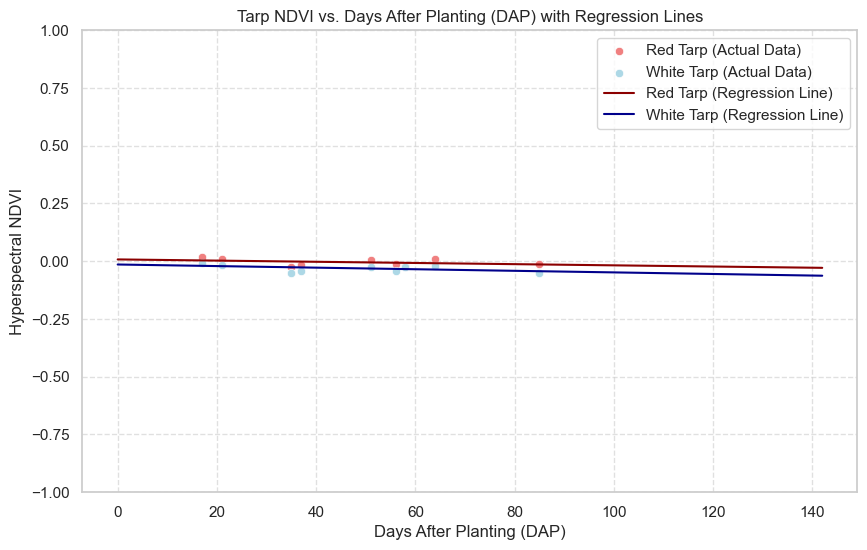

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Assuming the previous code has been run ---
# df_h_tarp: Your DataFrame with the original 'dap', 'red_tarp_NDVI', etc.
# models: The dictionary containing your trained 'red_model' and 'white_model'.
# dap_to_predict: The 2D array of DAP values (0-100) for prediction.
# predicted_red_ndvi: The array of predicted NDVI values for the red tarp.
# predicted_white_ndvi: The array of predicted NDVI values for the white tarp.
# --- End of assumed code ---


# 1. Create a figure and an axes object to draw on. This allows us to layer plots.
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot the original data points as scatter plots
sns.scatterplot(data=df_h_tarp, x='dap', y='red_tarp_NDVI', ax=ax, color='lightcoral', label='Red Tarp (Actual Data)')
sns.scatterplot(data=df_h_tarp, x='dap', y='white_tarp_NDVI', ax=ax, color='lightblue', label='White Tarp (Actual Data)')

# 3. Plot the regression lines using the predicted values
# We use .flatten() on dap_to_predict to make it a 1D array suitable for plotting
sns.lineplot(x=dap_to_predict.values.flatten(), y=predicted_red_ndvi, ax=ax, color='darkred', label='Red Tarp (Regression Line)')
sns.lineplot(x=dap_to_predict.values.flatten(), y=predicted_white_ndvi, ax=ax, color='darkblue', label='White Tarp (Regression Line)')

# 4. Customize the plot to make it clear and readable
ax.set_title('Tarp NDVI vs. Days After Planting (DAP) with Regression Lines')
ax.set_xlabel('Days After Planting (DAP)')
ax.set_ylabel('Hyperspectral NDVI')
ax.set_ylim(-1,1)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# 5. Display the final plot
plt.show()

In [165]:
df_dtw

,Unnamed: 0,dap_from_h_pixel,pixel_6_h_ndvi,dap_from_p6_scaled,pixel_6_ndvi,red_tarp_ndvi,white_tarp_ndvi,red_tarp_ndvi_resid,white_tarp_ndvi_resid,pixel_6_ndvi_minus_red_residual,...,pixel_6_ndvi_plus_red_residual,pixel_6_ndvi_plus_white_residual,predicted_red_tarp_ndvi,predicted_white_tarp_ndvi,predicted_red_tarp_ndvi_resid,predicted_white_tarp_ndvi_resid,pixel_6_ndvi_minus_predicted_red_residual,pixel_6_ndvi_minus_predicted_white_residual,pixel_6_ndvi_plus_predicted_red_residual,pixel_6_ndvi_plus_predicted_white_residual
0,0,7.0,0.097729,0.0,0.262583,0.449211,0.363141,-0.076507,-0.013027,0.339089,...,0.186076,0.249556,0.007592,-0.014406,0.441619,0.377547,-0.179036,-0.114964,0.704201,0.640129
1,1,17.0,0.132595,2.0,0.339088,0.487163,0.441322,-0.040617,0.063227,0.379704,...,0.298471,0.402314,0.007080,-0.015089,0.480084,0.456411,-0.140996,-0.117323,0.819171,0.795498
2,2,21.0,0.208185,10.0,0.296660,0.584590,0.486403,0.048561,0.100599,0.248100,...,0.345221,0.397259,0.005029,-0.017822,0.579561,0.504225,-0.282901,-0.207565,0.876221,0.800885
3,3,35.0,0.419410,11.0,0.304582,0.595419,0.446850,0.058358,0.060083,0.246224,...,0.362941,0.364666,0.004772,-0.018164,0.590646,0.465014,-0.286064,-0.160432,0.895228,0.769596
4,4,37.0,0.477401,12.0,0.300447,0.558860,0.385974,0.020769,-0.001757,0.279678,...,0.321216,0.298690,0.004516,-0.018506,0.554344,0.404479,-0.253898,-0.104033,0.854791,0.704926
5,5,51.0,0.884290,13.0,0.304124,0.523516,0.396422,-0.015606,0.007728,0.319731,...,0.288518,0.311852,0.004260,-0.018847,0.519256,0.415269,-0.215132,-0.111145,0.823381,0.719393
6,6,56.0,0.911712,14.0,0.296237,0.530978,0.373953,-0.009176,-0.015705,0.305413,...,0.287061,0.280532,0.004003,-0.019189,0.526974,0.393142,-0.230738,-0.096905,0.823211,0.689378
7,7,58.0,0.913091,15.0,0.321008,0.536437,0.370154,-0.004748,-0.020467,0.325756,...,0.316260,0.300540,0.003747,-0.019531,0.532690,0.389684,-0.211682,-0.068677,0.853697,0.710692
8,8,64.0,0.899013,17.0,0.254122,0.479224,0.311570,-0.064022,-0.080978,0.318145,...,0.190100,0.173145,0.003234,-0.020214,0.475990,0.331784,-0.221868,-0.077662,0.730113,0.585907
9,9,71.0,0.905247,30.0,0.462293,0.486053,0.246846,-0.070598,-0.158228,0.532891,...,0.391695,0.304065,-0.000099,-0.024655,0.486152,0.271502,-0.023859,0.190791,0.948445,0.733795


In [166]:
df_dtw.columns

Index(['Unnamed: 0', 'dap_from_h_pixel', 'pixel_6_h_ndvi',
       'dap_from_p6_scaled', 'pixel_6_ndvi', 'red_tarp_ndvi',
       'white_tarp_ndvi', 'red_tarp_ndvi_resid', 'white_tarp_ndvi_resid',
       'pixel_6_ndvi_minus_red_residual', 'pixel_6_ndvi_minus_white_residual',
       'pixel_6_ndvi_plus_red_residual', 'pixel_6_ndvi_plus_white_residual',
       'predicted_red_tarp_ndvi', 'predicted_white_tarp_ndvi',
       'predicted_red_tarp_ndvi_resid', 'predicted_white_tarp_ndvi_resid',
       'pixel_6_ndvi_minus_predicted_red_residual',
       'pixel_6_ndvi_minus_predicted_white_residual',
       'pixel_6_ndvi_plus_predicted_red_residual',
       'pixel_6_ndvi_plus_predicted_white_residual'],
      dtype='object')

In [167]:
from dtaidistance import dtw

# Prepare your data — drop NaNs and align
# valid_df = df_dtw[['pixel_6_h_ndvi', 'pixel_6_ndvi']].dropna()
dtw_columns = [ 'pixel_6_ndvi',
               'pixel_6_ndvi_minus_red_residual', 'pixel_6_ndvi_minus_white_residual',
               'pixel_6_ndvi_plus_red_residual', 'pixel_6_ndvi_plus_white_residual',
               'pixel_6_ndvi_minus_predicted_red_residual','pixel_6_ndvi_minus_predicted_white_residual',
               'pixel_6_ndvi_plus_predicted_red_residual','pixel_6_ndvi_plus_predicted_white_residual']
for col in dtw_columns:
    x = df_dtw['pixel_6_h_ndvi'].dropna().values
    y = df_dtw[col].dropna().values
    
    # Compute DTW distance
    distance = dtw.distance(x, y)

    print(f"DTW Distance for {col} : {distance}")

    # Optional: Get the warping path
    path = dtw.warping_path(x, y)
    print(f"Warping path length for {col} : {len(path)}")


DTW Distance for pixel_6_ndvi : 0.6090976535715961
Warping path length for pixel_6_ndvi : 26
DTW Distance for pixel_6_ndvi_minus_red_residual : 0.6063615737110427
Warping path length for pixel_6_ndvi_minus_red_residual : 24
DTW Distance for pixel_6_ndvi_minus_white_residual : 0.6320227019067362
Warping path length for pixel_6_ndvi_minus_white_residual : 24
DTW Distance for pixel_6_ndvi_plus_red_residual : 0.696689672776869
Warping path length for pixel_6_ndvi_plus_red_residual : 25
DTW Distance for pixel_6_ndvi_plus_white_residual : 0.6861138868723293
Warping path length for pixel_6_ndvi_plus_white_residual : 26
DTW Distance for pixel_6_ndvi_minus_predicted_red_residual : 2.2976916720681246
Warping path length for pixel_6_ndvi_minus_predicted_red_residual : 26
DTW Distance for pixel_6_ndvi_minus_predicted_white_residual : 1.985501858987162
Warping path length for pixel_6_ndvi_minus_predicted_white_residual : 23
DTW Distance for pixel_6_ndvi_plus_predicted_red_residual : 2.2982285212236

In [168]:

print("\n--- Recommended: Calculating DTW on First 13 Rows of Both X and Y ---")
for col in dtw_columns:
    # FIX 1: Slice x to its first 13 rows
    x_1 = df_dtw['pixel_6_h_ndvi'].iloc[:13].dropna().values
    
    # FIX 2: Slice y to its first 13 rows
    y_1 = df_dtw[col].iloc[:13].dropna().values
    
    # Now you are comparing two series of the same length
    distance_1 = dtw.distance(x_1, y_1)
    print(f"DTW Distance for {col} : {distance_1:.4f}")
    # Optional: Get the warping path
    path_1 = dtw.warping_path(x_1, y_1)
    print(f"Warping path length for {col} : {len(path_1)}")


--- Recommended: Calculating DTW on First 13 Rows of Both X and Y ---
DTW Distance for pixel_6_ndvi : 0.3600
Warping path length for pixel_6_ndvi : 19
DTW Distance for pixel_6_ndvi_minus_red_residual : 0.4566
Warping path length for pixel_6_ndvi_minus_red_residual : 17
DTW Distance for pixel_6_ndvi_minus_white_residual : 0.3816
Warping path length for pixel_6_ndvi_minus_white_residual : 17
DTW Distance for pixel_6_ndvi_plus_red_residual : 0.3339
Warping path length for pixel_6_ndvi_plus_red_residual : 19
DTW Distance for pixel_6_ndvi_plus_white_residual : 0.4696
Warping path length for pixel_6_ndvi_plus_white_residual : 18
DTW Distance for pixel_6_ndvi_minus_predicted_red_residual : 1.9498
Warping path length for pixel_6_ndvi_minus_predicted_red_residual : 20
DTW Distance for pixel_6_ndvi_minus_predicted_white_residual : 1.2863
Warping path length for pixel_6_ndvi_minus_predicted_white_residual : 19
DTW Distance for pixel_6_ndvi_plus_predicted_red_residual : 1.4865
Warping path length

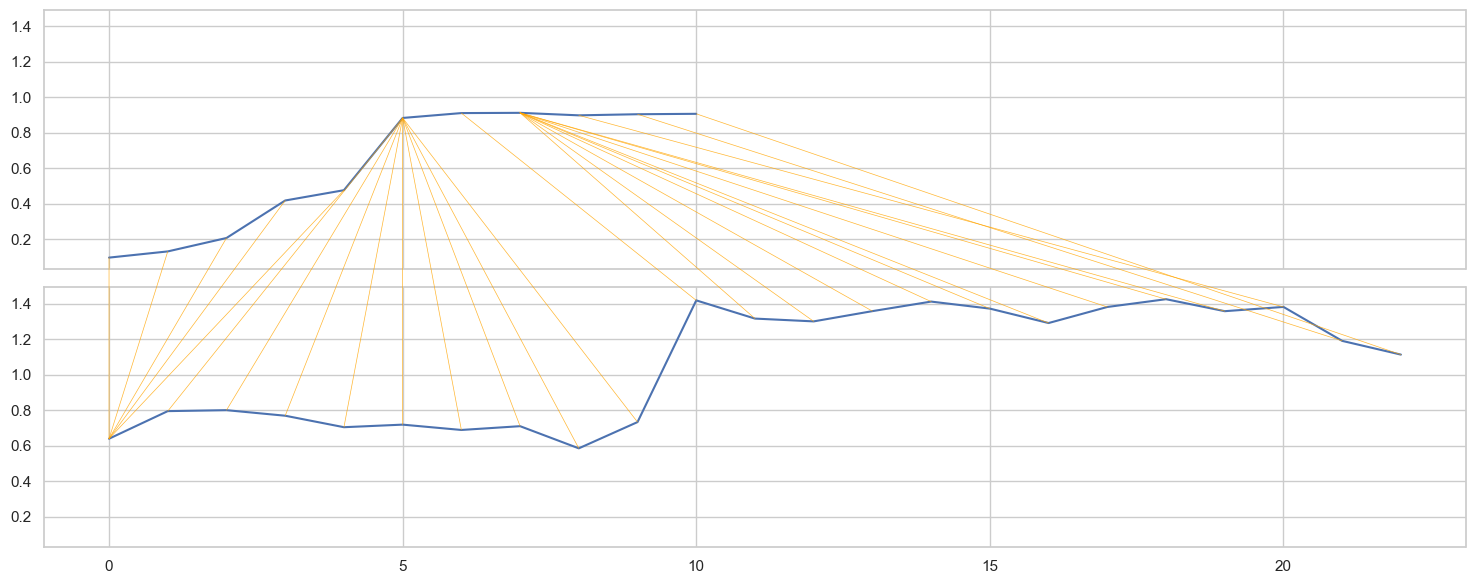

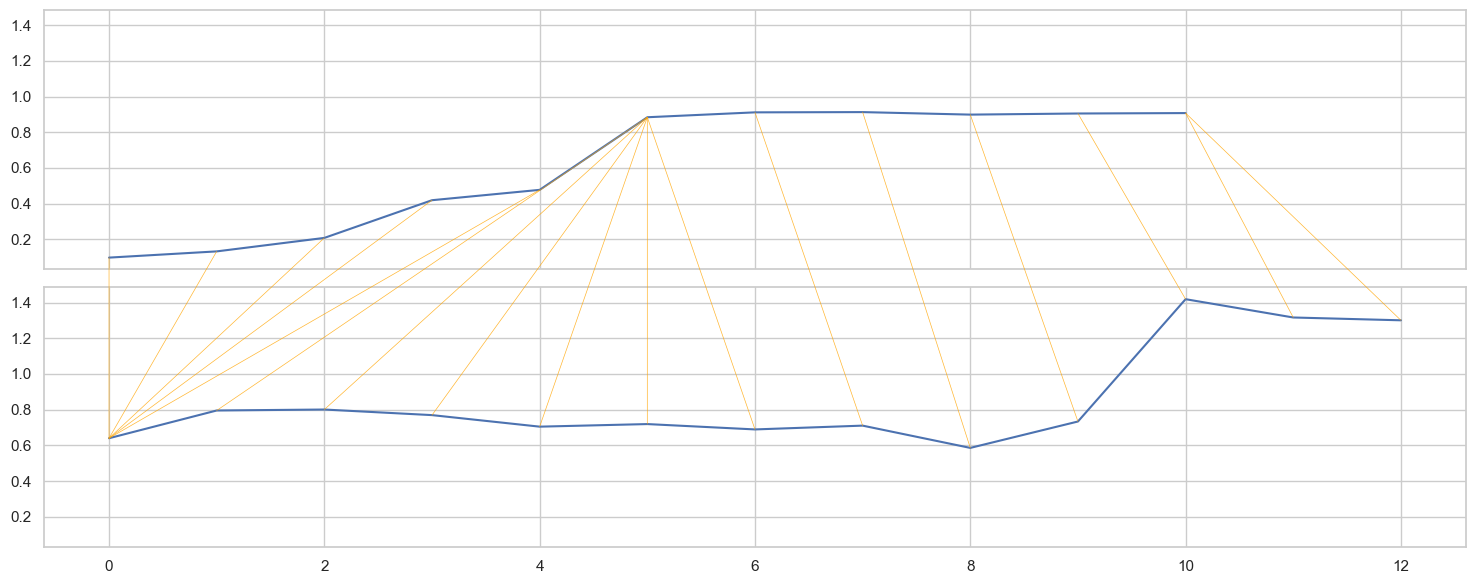

In [169]:
from dtaidistance import dtw_visualisation as dtwvis
import matplotlib.pyplot as plt

dtwvis.plot_warping(x, y, path)
dtwvis.plot_warping(x_1, y_1, path_1)
plt.show()


# TRying the same but with red and NIR bands fro red tarp

In [172]:
df_red_tarp = df_p6_scaled.iloc[33:]

In [174]:
df_red_tarp.drop(columns= ['date','year','pixel_6_NDVI','red_tarp_NDVI','white_tarp_NDVI'])

,days_after_planting,pixel_6_red,pixel_6_NIR,red_tarp_red,white_tarp_red,red_tarp_NIR,white_tarp_NIR
33,0.0,0.000016,0.000028,0.000020,0.000026,0.000052,0.000055
34,2.0,0.000013,0.000027,0.000016,0.000020,0.000048,0.000051
35,10.0,0.000015,0.000027,0.000012,0.000017,0.000047,0.000049
36,11.0,0.000015,0.000028,0.000012,0.000020,0.000048,0.000053
37,12.0,0.000014,0.000026,0.000012,0.000020,0.000043,0.000046
38,13.0,0.000015,0.000028,0.000014,0.000021,0.000046,0.000047
39,14.0,0.000016,0.000029,0.000014,0.000023,0.000045,0.000050
40,15.0,0.000015,0.000029,0.000014,0.000023,0.000048,0.000050
41,17.0,0.000017,0.000028,0.000015,0.000026,0.000043,0.000050
42,30.0,0.000008,0.000022,0.000012,0.000022,0.000034,0.000037
